# **Disease Prediction Using Machine Learning**

## **Import & Load the Data**

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (18).zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to: {extract_dir}")

# List the extracted files
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

Files extracted to: /content/extracted_data
Contents of the extracted directory:
/content/extracted_data/Testing.csv
/content/extracted_data/Training.csv


In [ ]:
import pandas as pd

training_csv_path = '/content/extracted_data/Training.csv'
testing_csv_path = '/content/extracted_data/Testing.csv'

train_df = pd.read_csv(training_csv_path)
test_df = pd.read_csv(testing_csv_path)

print("Training data loaded. First 5 rows:")
print(train_df.head())
print("\nTesting data loaded. First 5 rows:")
print(test_df.head())

Training data loaded. First 5 rows:
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  scurring  \
0       0           0             0        0                 0  ...         0   
1       0           0             0        0                 0  ...         0   
2       0           0             0        0                 0  ...         0   
3       0           0             0        0                 0  ...         0   
4       0           0             0        0                 0  ...         0   

  

In [ ]:
print("\n--- Training DataFrame Info ---")
train_df.info()
print("\n--- Testing DataFrame Info ---")
test_df.info()

print("\nShape of Training DataFrame:", train_df.shape)
print("Shape of Testing DataFrame:", test_df.shape)

print("\nColumns in Training DataFrame:", train_df.columns.tolist())
print("Columns in Testing DataFrame:", test_df.columns.tolist())


--- Training DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB

--- Testing DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 43.8+ KB

Shape of Training DataFrame: (4920, 134)
Shape of Testing DataFrame: (42, 133)

Columns in Training DataFrame: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydra

# Check Data shape

In [ ]:
print("Shape of Training DataFrame:", train_df.shape)
print("Shape of Testing DataFrame:", test_df.shape)

Shape of Training DataFrame: (4920, 134)
Shape of Testing DataFrame: (42, 133)


# Drop unnecessary columns, Check Missing Values & check duplicates

In [ ]:
# Drop the 'Unnamed: 133' column from train_df if it exists
if 'Unnamed: 133' in train_df.columns:
    train_df = train_df.drop('Unnamed: 133', axis=1)
    print("Dropped 'Unnamed: 133' column from train_df.\n")

print("--- Dataset Information ---\n")

print("Shape of Training DataFrame:", train_df.shape)
print("Shape of Testing DataFrame:", test_df.shape)

print("\nMissing values in Training DataFrame:")
print(train_df.isnull().sum().sum())

print("\nMissing values in Testing DataFrame:")
print(test_df.isnull().sum().sum())

print("\nNumber of duplicate rows in Training DataFrame:", train_df.duplicated().sum())
print("Number of duplicate rows in Testing DataFrame:", test_df.duplicated().sum())

print("\n--- Training DataFrame Info ---")
train_df.info()
print("\n--- Testing DataFrame Info ---")
test_df.info()

Dropped 'Unnamed: 133' column from train_df.

--- Dataset Information ---

Shape of Training DataFrame: (4920, 133)
Shape of Testing DataFrame: (42, 133)

Missing values in Training DataFrame:
0

Missing values in Testing DataFrame:
0

Number of duplicate rows in Training DataFrame: 4616
Number of duplicate rows in Testing DataFrame: 0

--- Training DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB

--- Testing DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 43.8+ KB


# Remove duplicate

In [ ]:
print("Shape of train_df BEFORE removing duplicates:", train_df.shape)

train_df.drop_duplicates(inplace=True)

print("Shape of train_df AFTER removing duplicates:", train_df.shape)
print("Number of duplicate rows in Training DataFrame AFTER removal:", train_df.duplicated().sum())

Shape of train_df BEFORE removing duplicates: (4920, 133)
Shape of train_df AFTER removing duplicates: (304, 133)
Number of duplicate rows in Training DataFrame AFTER removal: 0


# Show the distribution of the 'prognosis' column in train

In [ ]:
print("Distribution of 'prognosis' in Training DataFrame:")
display(train_df['prognosis'].value_counts())

Distribution of 'prognosis' in Training DataFrame:


,count
prognosis,
Migraine,10
Dengue,10
Hepatitis D,10
Chicken pox,10
Typhoid,9
Hepatitis B,9
Jaundice,9
hepatitis A,9
Diabetes,9


/tmp/ipykernel_3382/1168801795.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prognosis_counts.index, y=prognosis_counts.values, palette='viridis')


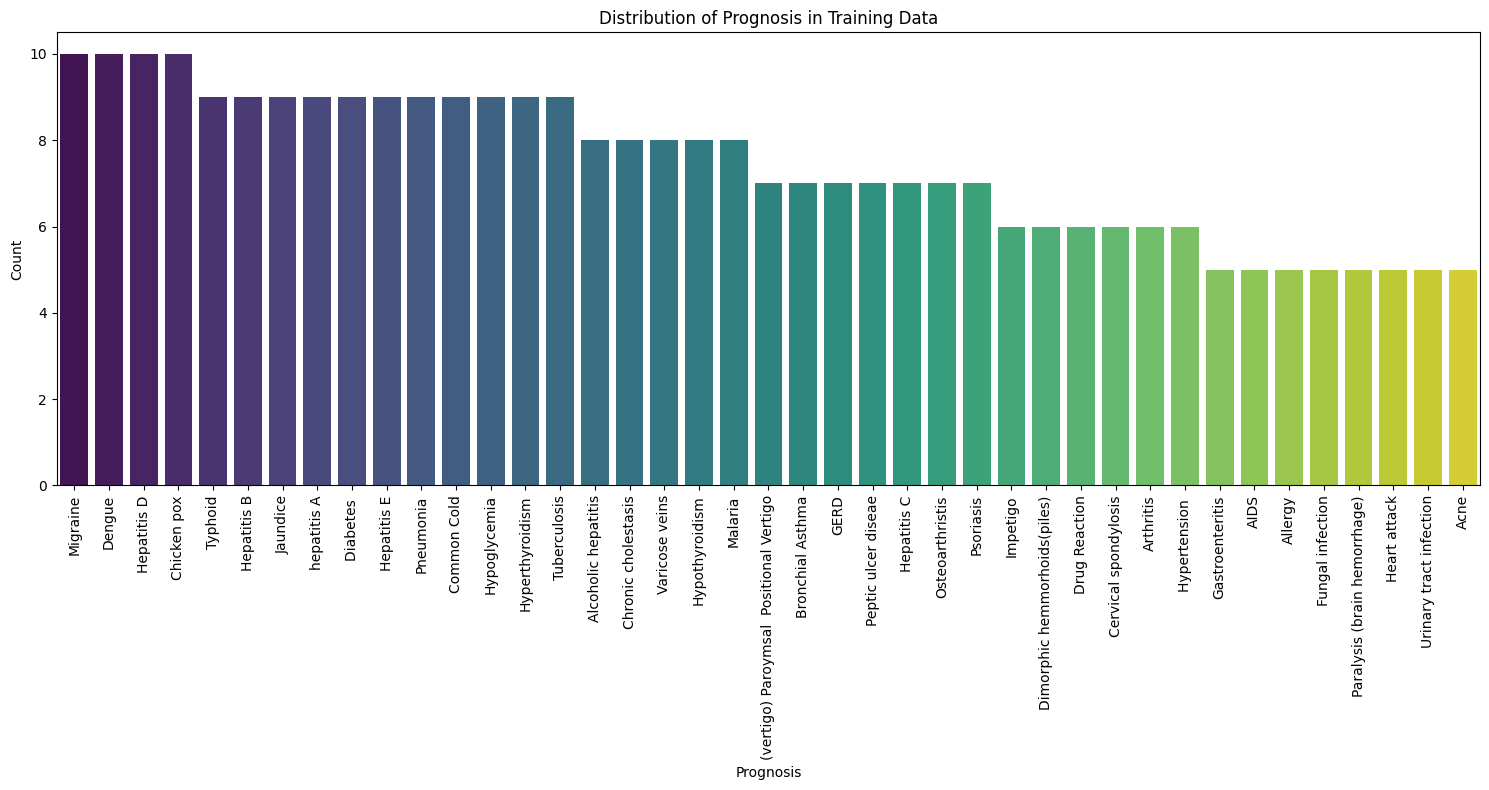

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts for the 'prognosis' column
prognosis_counts = train_df['prognosis'].value_counts()

# Create a bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x=prognosis_counts.index, y=prognosis_counts.values, palette='viridis')
plt.xlabel('Prognosis')
plt.ylabel('Count')
plt.title('Distribution of Prognosis in Training Data')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Top 20 Most Frequent Symptoms

In [ ]:
# Exclude the 'prognosis' column to get only symptom columns
symptom_columns = train_df.columns.drop('prognosis')

# Calculate the sum of each symptom (since values are 0 or 1, sum represents count)
symptom_counts = train_df[symptom_columns].sum().sort_values(ascending=False)

# Get the top 20 most frequent symptoms
top_20_symptoms = symptom_counts.head(20)

print("Top 20 Most Frequent Symptoms:")
display(top_20_symptoms)

Top 20 Most Frequent Symptoms:


,0
fatigue,134
vomiting,117
high_fever,89
loss_of_appetite,81
nausea,77
headache,74
abdominal_pain,70
yellowish_skin,61
yellowing_of_eyes,58
malaise,53


/tmp/ipykernel_3382/143156382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_symptoms.index, y=top_20_symptoms.values, palette='coolwarm')


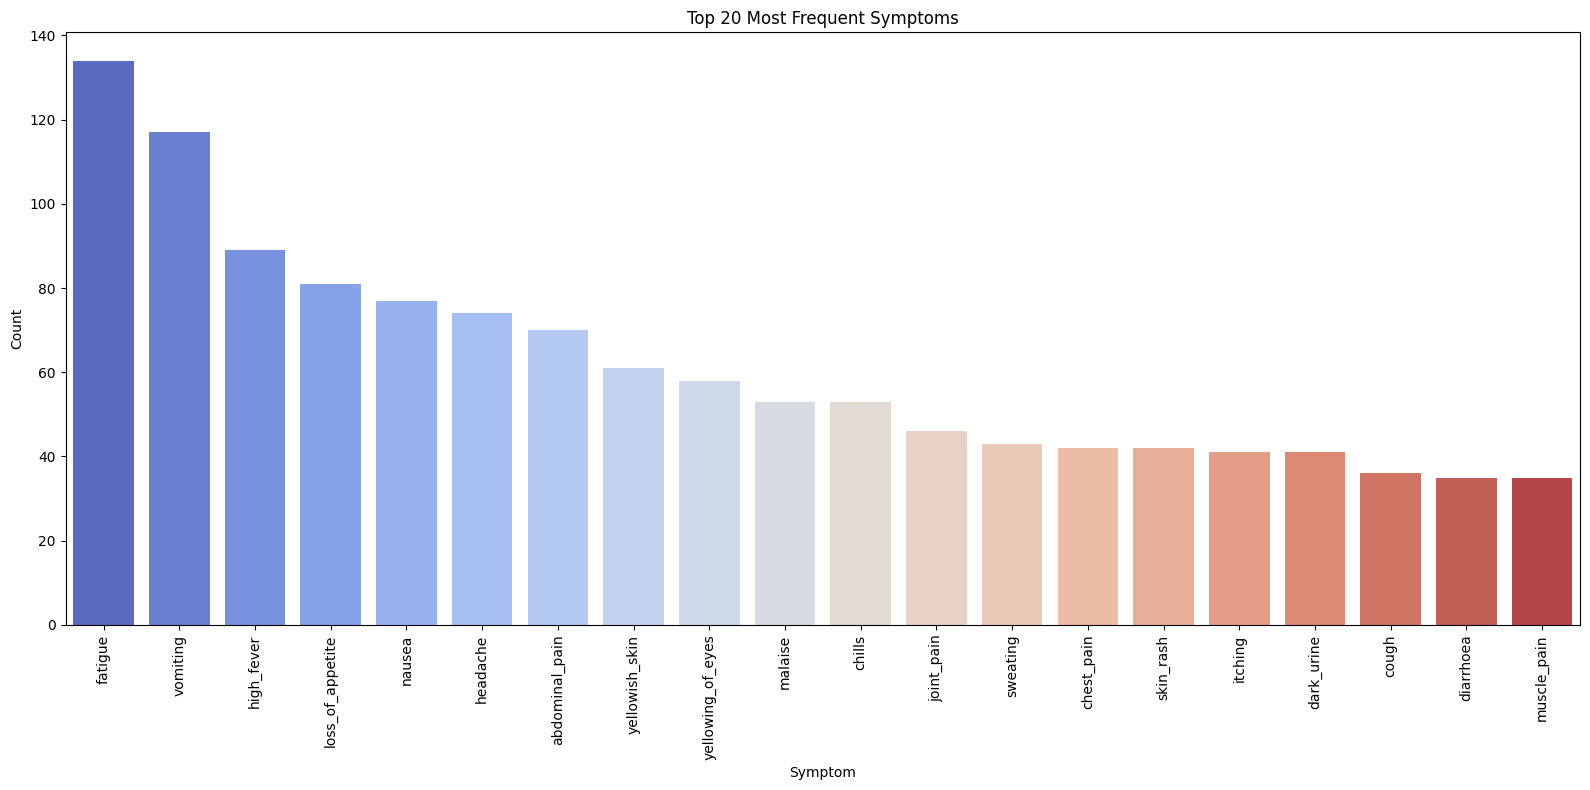

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.barplot(x=top_20_symptoms.index, y=top_20_symptoms.values, palette='coolwarm')
plt.xlabel('Symptom')
plt.ylabel('Count')
plt.title('Top 20 Most Frequent Symptoms')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

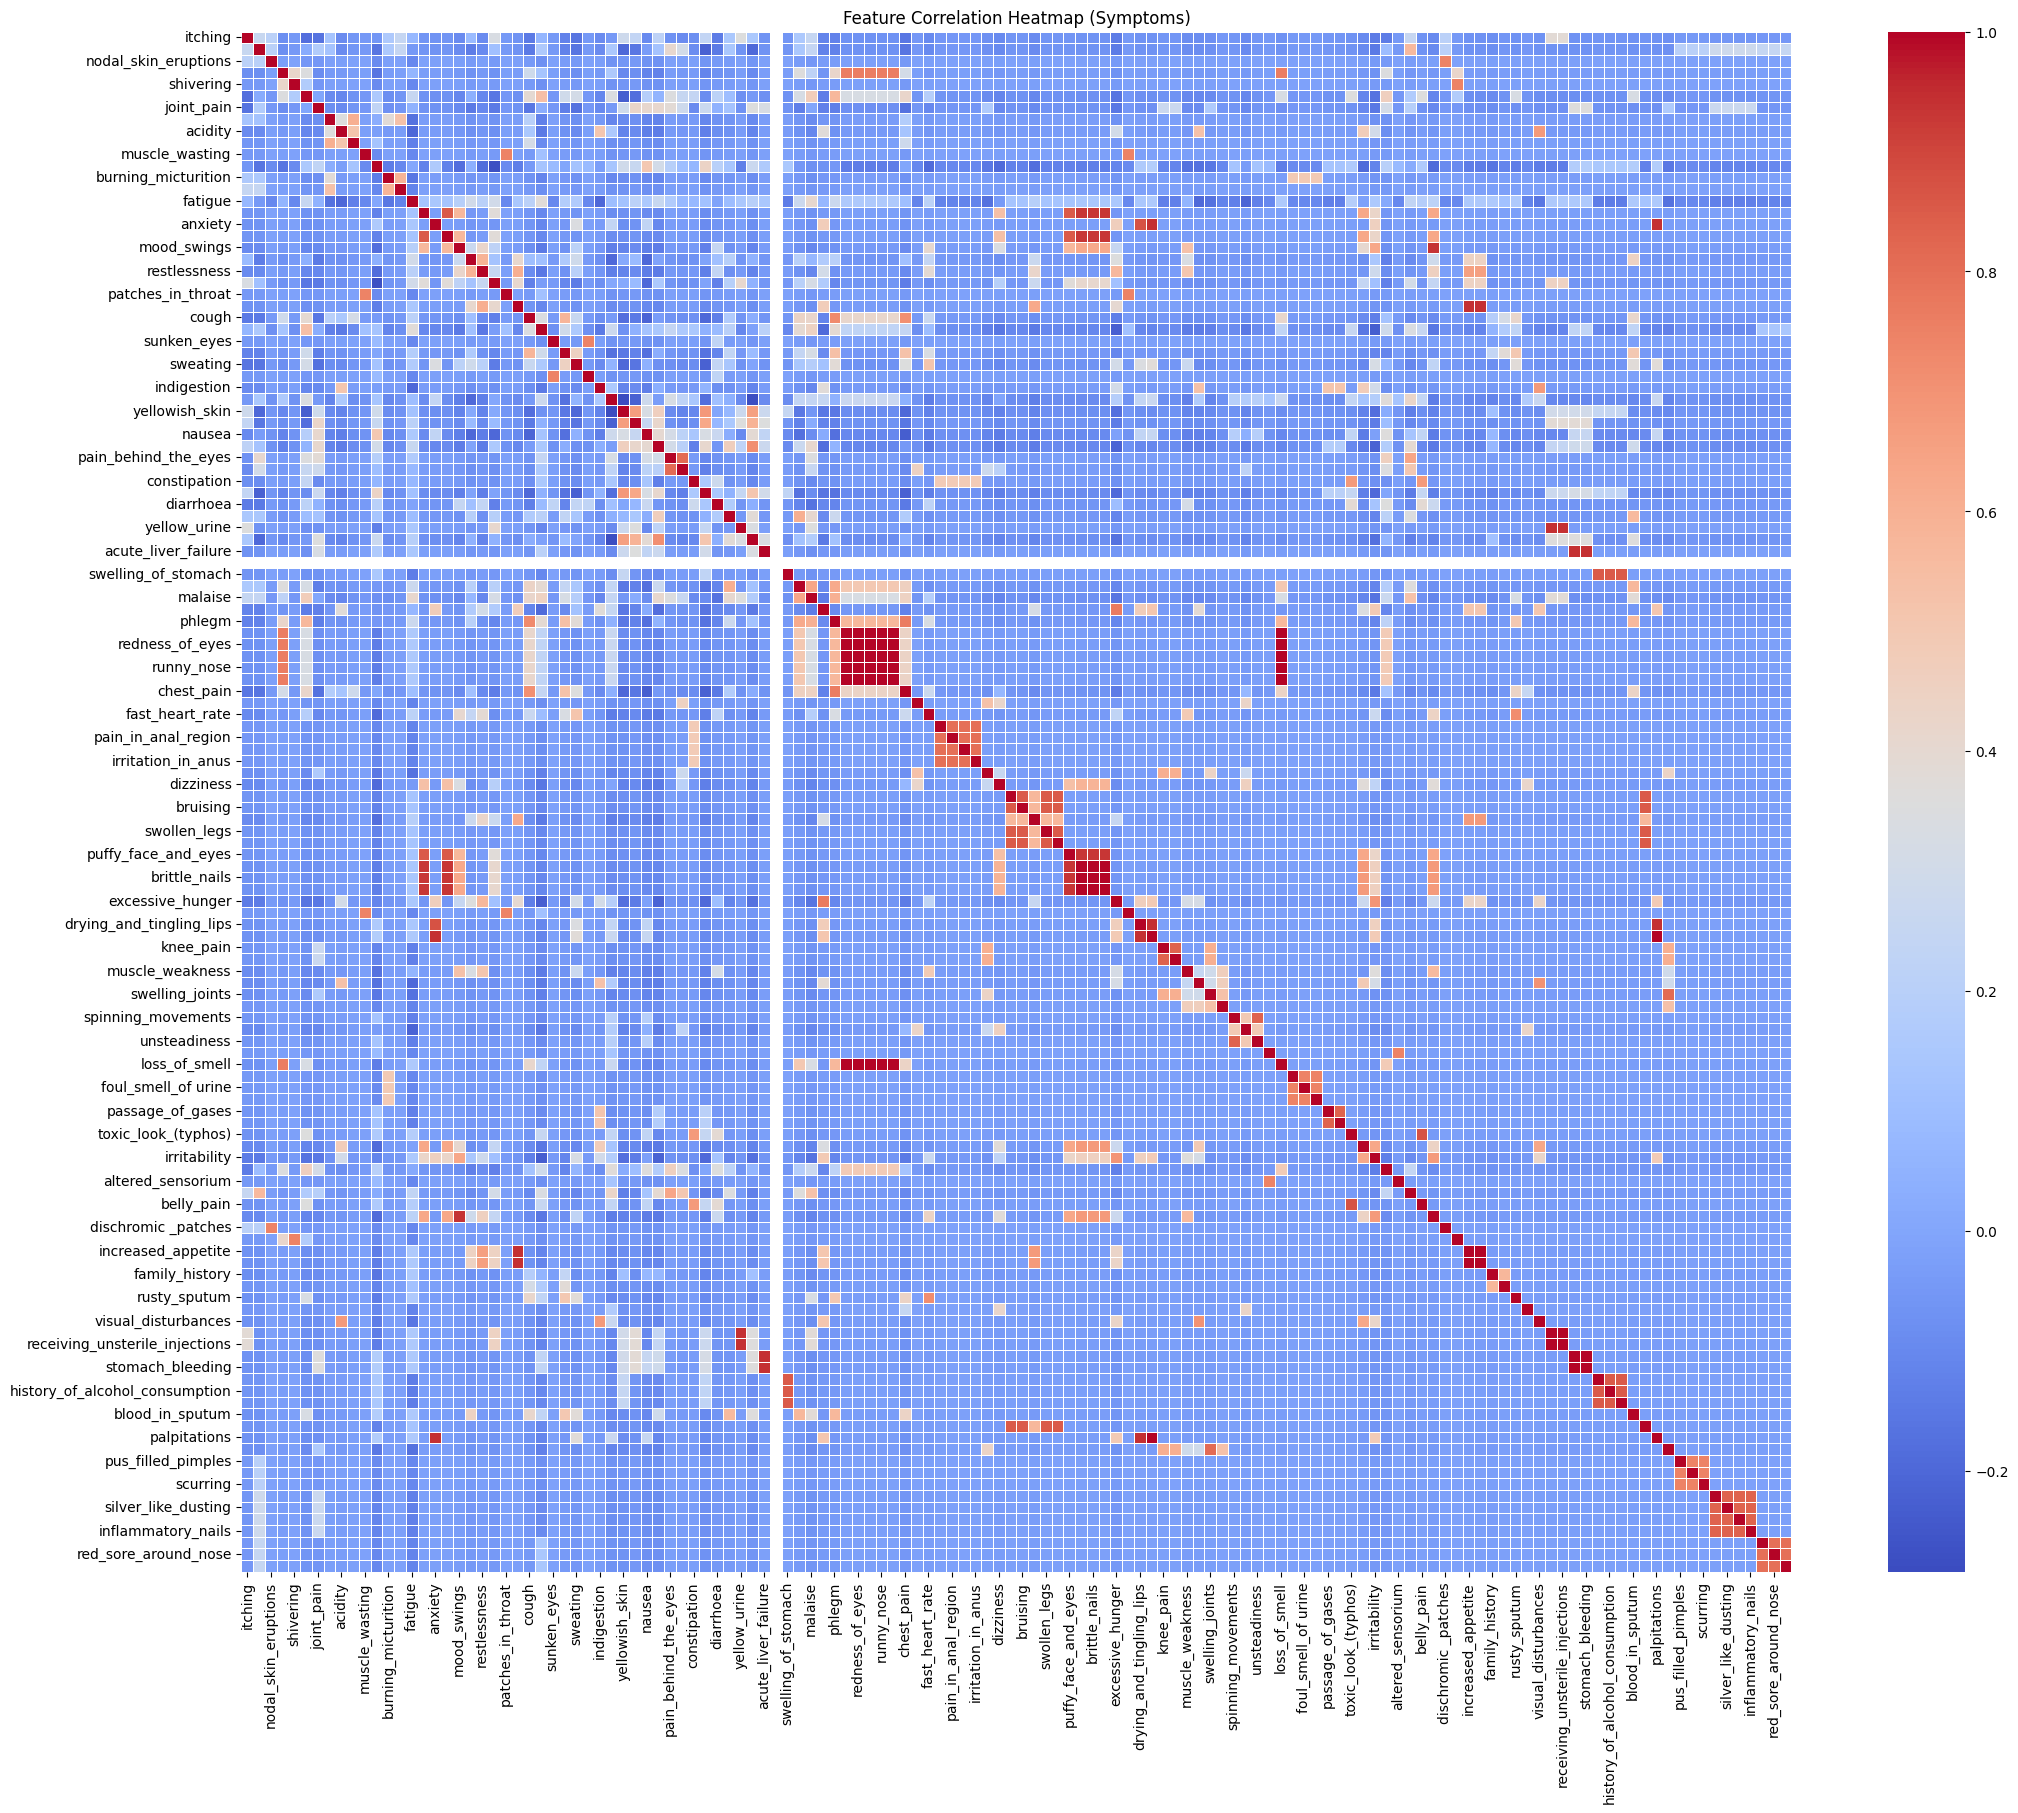

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'prognosis' column for correlation calculation
symptom_data = train_df.drop('prognosis', axis=1)

# Calculate the correlation matrix
correlation_matrix = symptom_data.corr()

# Create a heatmap
plt.figure(figsize=(25, 20)) # Adjust figure size for better readability with many features
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap (Symptoms)')
plt.show()

## Label Encoding the Target Variable

## Target Encoding

The `prognosis` column has already been dropped from `X_train` and `X_test` when they were created in the previous step.

Here are the first few rows of the feature dataframes to confirm:

In [ ]:
print("X_train head (without 'prognosis' column):")
display(X_train.head())

X_train head (without 'prognosis' column):


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print("\nX_test head (without 'prognosis' column):")
display(X_test.head())


X_test head (without 'prognosis' column):


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## Model Training: RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the RandomForestClassifier
# Using random_state for reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train_encoded)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


## Model Evaluation

In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))


Accuracy: 1.0000

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1

## Model Training: LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the LogisticRegression model
# Using random_state for reproducibility and max_iter for convergence
logistic_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')

# Train the model
logistic_model.fit(X_train, y_train_encoded)

print("LogisticRegression model trained successfully.")

LogisticRegression model trained successfully.


## LogisticRegression Model Evaluation

In [ ]:
# Make predictions on the test set using the LogisticRegression model
y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test_encoded, y_pred_lr)
print(f"LogisticRegression Accuracy: {accuracy_lr:.4f}")

# Display classification report
print("\nLogisticRegression Classification Report:")
print(classification_report(y_test_encoded, y_pred_lr, target_names=label_encoder.classes_))

LogisticRegression Accuracy: 0.9762

LogisticRegression Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            C

## Model Training: DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier
# Using random_state for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train_encoded)

print("DecisionTreeClassifier trained successfully.")

DecisionTreeClassifier trained successfully.


## DecisionTreeClassifier Model Evaluation

In [ ]:
# Make predictions on the test set using the DecisionTreeClassifier
y_pred_dt = dt_classifier.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test_encoded, y_pred_dt)
print(f"DecisionTreeClassifier Accuracy: {accuracy_dt:.4f}")

# Display classification report
print("\nDecisionTreeClassifier Classification Report:")
print(classification_report(y_test_encoded, y_pred_dt, target_names=label_encoder.classes_))

DecisionTreeClassifier Accuracy: 0.9762

DecisionTreeClassifier Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                     

## Model Training: Support Vector Machine (SVC)

In [ ]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier
# Using random_state for reproducibility
svm_classifier = SVC(random_state=42)

# Train the model
svm_classifier.fit(X_train, y_train_encoded)

print("Support Vector Classifier trained successfully.")

Support Vector Classifier trained successfully.


## Support Vector Machine (SVC) Model Evaluation

In [ ]:
# Make predictions on the test set using the Support Vector Classifier
y_pred_svm = svm_classifier.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_encoded, y_pred_svm)
print(f"Support Vector Classifier Accuracy: {accuracy_svm:.4f}")

# Display classification report
print("\nSupport Vector Classifier Classification Report:")
print(classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder.classes_))

Support Vector Classifier Accuracy: 1.0000

Support Vector Classifier Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
               

## Model Training: Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes classifier
gnb_classifier = GaussianNB()

# Train the model
gnb_classifier.fit(X_train, y_train_encoded)

print("Gaussian Naive Bayes classifier trained successfully.")

Gaussian Naive Bayes classifier trained successfully.


## Gaussian Naive Bayes Model Evaluation

In [ ]:
# Make predictions on the test set using the Gaussian Naive Bayes classifier
y_pred_gnb = gnb_classifier.predict(X_test)

# Calculate accuracy
accuracy_gnb = accuracy_score(y_test_encoded, y_pred_gnb)
print(f"Gaussian Naive Bayes Accuracy: {accuracy_gnb:.4f}")

# Display classification report
print("\nGaussian Naive Bayes Classification Report:")
print(classification_report(y_test_encoded, y_pred_gnb, target_names=label_encoder.classes_))

Gaussian Naive Bayes Accuracy: 1.0000

Gaussian Naive Bayes Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                         

## Model Training: XGBoost Classifier

In [ ]:
import xgboost as xgb

# Initialize the XGBoost Classifier
# Using random_state for reproducibility
xgb_classifier = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Train the model
xgb_classifier.fit(X_train, y_train_encoded)

print("XGBoost Classifier trained successfully.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:11:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully.


## XGBoost Classifier Model Evaluation

In [ ]:
# Make predictions on the test set using the XGBoost Classifier
y_pred_xgb = xgb_classifier.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")

# Display classification report
print("\nXGBoost Classifier Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder.classes_))

XGBoost Classifier Accuracy: 0.9762

XGBoost Classifier Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            C

## Model Comparison

/tmp/ipykernel_3382/1944838441.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


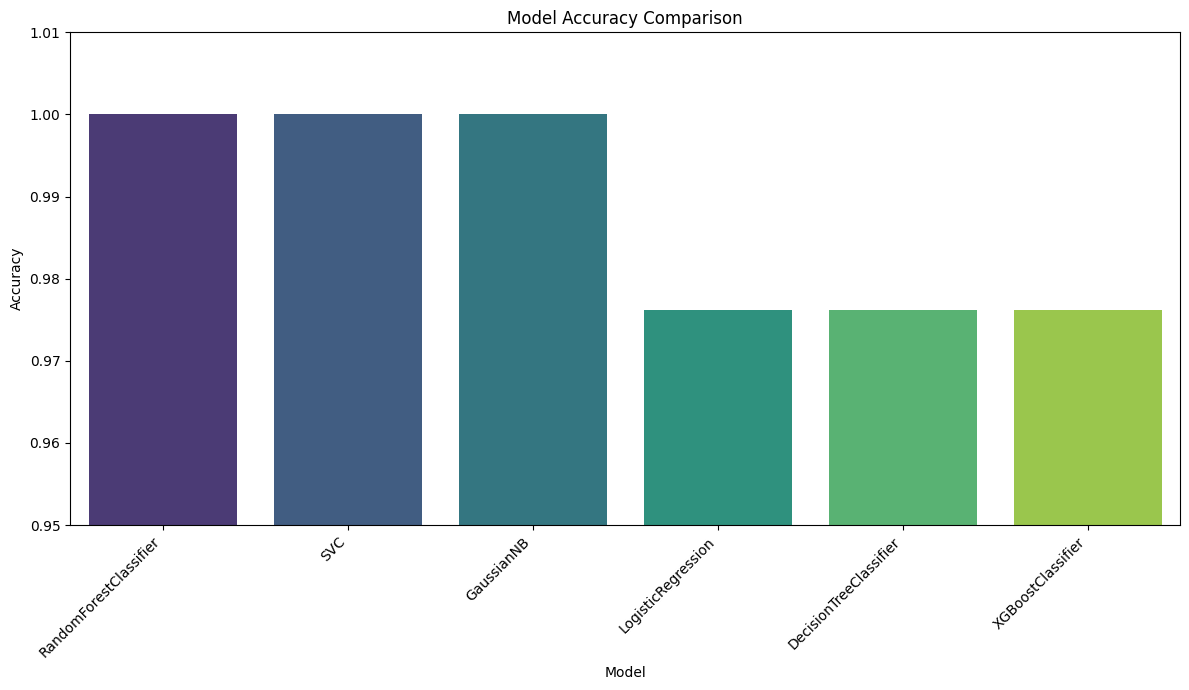

,Model,Accuracy
0,RandomForestClassifier,1.00000
3,SVC,1.00000
4,GaussianNB,1.00000
1,LogisticRegression,0.97619
2,DecisionTreeClassifier,0.97619
5,XGBoostClassifier,0.97619


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store model accuracies
model_accuracies = {
    'RandomForestClassifier': accuracy,
    'LogisticRegression': accuracy_lr,
    'DecisionTreeClassifier': accuracy_dt,
    'SVC': accuracy_svm,
    'GaussianNB': accuracy_gnb,
    'XGBoostClassifier': accuracy_xgb
}

# Convert the dictionary to a DataFrame
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

# Sort the DataFrame by accuracy in descending order
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.01) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(accuracy_df)

## Using the RandomForestClassifier for Prediction

In [ ]:
# The `rf_classifier` model was already trained and is available.
# The `label_encoder` was also fitted and is available for inverse transformation.

print("RandomForestClassifier is ready for predictions.")

RandomForestClassifier is ready for predictions.


To make a prediction, we need to create a new input sample with the same features as the training data. For demonstration, let's take one random sample from the `X_test` dataset as an example input for prediction.

In [ ]:
# Select a sample from X_test for prediction demonstration
sample_index = 0 # You can change this index to pick a different sample
example_input = X_test.iloc[[sample_index]]

print(f"Example input (sample index {sample_index}):")
display(example_input)

# Get the actual prognosis for comparison
actual_prognosis_encoded = y_test_encoded[sample_index]
actual_prognosis_label = label_encoder.inverse_transform([actual_prognosis_encoded])[0]
print(f"Actual prognosis for this sample: {actual_prognosis_label}")

Example input (sample index 0):


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Actual prognosis for this sample: Fungal infection


In [ ]:
# Make a prediction using the RandomForestClassifier
predicted_prognosis_encoded = rf_classifier.predict(example_input)

# Decode the predicted prognosis back to its original label
predicted_prognosis_label = label_encoder.inverse_transform(predicted_prognosis_encoded)[0]

print(f"Predicted prognosis for the sample: {predicted_prognosis_label}")

Predicted prognosis for the sample: Fungal infection


## Saving the Model

In [ ]:
import joblib

# Define the filename for saving the model
model_filename = 'random_forest_classifier_model.joblib'

# Save the trained model
joblib.dump(rf_classifier, model_filename)

print(f"Model saved successfully to {model_filename}")
print("You can download this file from the Colab file browser (left panel) or move it to Google Drive if connected.")

Model saved successfully to random_forest_classifier_model.joblib
You can download this file from the Colab file browser (left panel) or move it to Google Drive if connected.
